2025-06-28 19:22:21.786948: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-28 19:22:21.786997: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-28 19:22:21.787042: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Run 1/5 — Latency: 72.64±197.47 ms | MSE: 6.034589e-03 | Grad: 4.378005e-01 | Loss: 1.041259e-02
Run 2/5 — Latency: 28.76±1.13 ms | MSE: 6.034589e-03 | Grad: 4.378005e-01 | Loss: 1.041259e-02
Run 3/5 — Latency: 29.99±1.33 ms | MSE: 6.034589e-03 | Grad: 4.378005e-01 | Loss: 1.041259e-02
Run 4/5 — Latency: 32.10±1.57 ms | MSE: 6.034589e-03 | Grad: 4.378005e-01 | Loss: 1.041259e-02
Run 5/5 — Latency: 35.06±3.30 ms | MSE: 6.034589e-03 | Grad: 4.378005e-01 | Loss: 1.041259e-02

Overall mean latency: 39.71 ms
Overall std latency:  40.96 ms


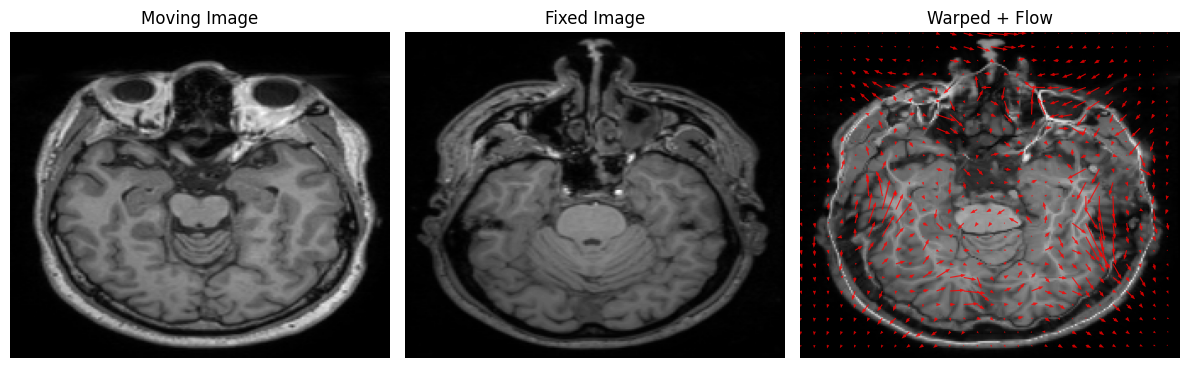

In [ ]:
import os
import time
import cv2
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from voxelmorph.tf.layers import SpatialTransformer
from voxelmorph.tf.losses import Grad

MODEL_PATH = '../training/models/vxm2d_model_ez.h5'
DATA_DIR = '../../workspace/calibration_dataset'
NUM_SAMPLES = 20
NUM_RUNS = 5

def load_pair(idx):
    arr = np.load(os.path.join(DATA_DIR, f'calib_pair_{idx}.npy'), allow_pickle=True)
    mov = arr[0][...,0].astype(np.float32)
    fix = arr[1][...,0].astype(np.float32)
    return mov, fix

def init_models():
    base = tf.keras.models.load_model(
        MODEL_PATH,
        custom_objects={'SpatialTransformer': SpatialTransformer},
        compile=False
    )
    base.compile(optimizer='adam',
                 loss=['mse', Grad('l2')],
                 loss_weights=[1.0, 0.01])
    feat_extractor = tf.keras.Model(
        inputs=base.inputs,
        outputs=base.get_layer('leaky_re_lu_118').output
    )
    return base, feat_extractor

def warp_image(model, mov, fix):
    _, flow = model.predict([mov[None], fix[None]], verbose=0)
    flow = flow[0]
    h, w = flow.shape[:2]
    gx, gy = np.meshgrid(np.arange(w), np.arange(h))
    mx = (gx + flow[...,1]).astype(np.float32)
    my = (gy + flow[...,0]).astype(np.float32)
    warped = cv2.remap(mov, mx, my, cv2.INTER_LINEAR, cv2.BORDER_REFLECT)
    return flow, warped

def compute_metrics(warped, fix, flow):
    mse = np.mean((warped - fix)**2)
    dx = flow[1:] - flow[:-1]
    dy = flow[:,1:] - flow[:,:-1]
    grad_norm = (np.sum(dx*dx) + np.sum(dy*dy)) / np.prod(flow.shape)
    total = mse + 0.01 * grad_norm
    return mse, grad_norm, total

base_model, extractor = init_models()

all_means = []
all_stds = []

for run in range(1, NUM_RUNS+1):
    latencies = []
    mses = []
    grads = []
    losses = []
    
    for i in range(NUM_SAMPLES):
        mov, fix = load_pair(i)
        t0 = time.perf_counter()
        _ = extractor.predict([mov[None], fix[None]], verbose=0)
        t1 = time.perf_counter()
        lat_ms = (t1 - t0) * 1e3
        latencies.append(lat_ms)
        
        flow, warped = warp_image(base_model, mov, fix)
        mse, grad_norm, loss = compute_metrics(warped, fix, flow)
        mses.append(mse)
        grads.append(grad_norm)
        losses.append(loss)
        
        if i == 0:
            first_flow, first_mov, first_fix, first_warp = flow, mov, fix, warped
    
    lat_arr = np.array(latencies)
    all_means.append(lat_arr.mean())
    all_stds.append(lat_arr.std())
    
    print(f'Run {run}/{NUM_RUNS} — '
          f'Latency: {lat_arr.mean():.2f}±{lat_arr.std():.2f} ms | '
          f'MSE: {np.mean(mses):.6e} | '
          f'Grad: {np.mean(grads):.6e} | '
          f'Loss: {np.mean(losses):.6e}')

lat_mean = np.array(all_means)
lat_std  = np.array(all_stds)

print(f'\nOverall mean latency: {lat_mean.mean():.2f} ms')
print(f'Overall std latency:  {lat_std.mean():.2f} ms')

np.save('results/cpu/latency_mean_cpu.npy', lat_mean)
np.save('results/cpu/latency_sd_cpu.npy', lat_std)
np.save('results/cpu/loss_results_cpu.npy', {
    'mse': np.mean(mses),
    'grad': np.mean(grads),
    'loss': np.mean(losses)
})

u, v = first_flow[...,0], first_flow[...,1]
step = 8
ys, xs = np.arange(0, first_warp.shape[0], step), np.arange(0, first_warp.shape[1], step)
X, Y = np.meshgrid(xs, ys)
U, V = u[::step, ::step], v[::step, ::step]

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(first_mov, cmap='gray')
plt.title('Moving Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(first_fix, cmap='gray')
plt.title('Fixed Image')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(first_warp, cmap='gray')
plt.quiver(X, Y, U, V, angles='xy', scale_units='xy', scale=1,
           width=0.003, headwidth=3, headlength=4, alpha=0.8, color='r')
plt.title('Warped + Flow')
plt.axis('off')

plt.tight_layout()
plt.show()